## **Customer Churn Prediction**


This project will include:

1.  EDA (Exploratory Data Analysis): Explore the behavior of churned users and make recommendations.
2.  Supervised Learning: Build a Machine Learning model to predict user churn.
3.  Unsupervised Learning: Segment churned users into different groups based on their behavior.

## **A. EDA**

### **Bước 1: Data Cleaning (Làm sạch dữ liệu)**

1.1 Kiểm tra tổng quan & Xử lý giá trị thiếu

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel('/content/churn_prediction.xlsx')

# Kiểm tra thông tin tổng quát và giá trị thiếu
print(df.head())
print(df.info())
print((df.describe(include='all')))

   CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  WarehouseToHome  \
0       52869      0    20.0         Mobile Phone         3              7.0   
1       52942      0    13.0             Computer         1              9.0   
2       52972      0    16.0         Mobile Phone         3              7.0   
3       53125      0     5.0         Mobile Phone         1             16.0   
4       53367      0     9.0         Mobile Phone         1             28.0   

  PreferredPaymentMode  Gender  HourSpendOnApp  NumberOfDeviceRegistered  \
0             E wallet  Female             4.0                         4   
1     Cash on Delivery  Female             4.0                         4   
2           Debit Card    Male             3.0                         4   
3           Debit Card    Male             3.0                         4   
4           Debit Card  Female             3.0                         4   

     PreferedOrderCat  SatisfactionScore MaritalStatus  Number

In [ ]:
# Missing  Data
df.isnull().sum()

,0
CustomerID,0
Churn,0
Tenure,264
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,251
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,255
NumberOfDeviceRegistered,0


In [ ]:
# Duplicate Data
df.duplicated().sum()

np.int64(0)

In [ ]:
num_cols

Index(['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome',
       'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore',
       'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear',
       'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

In [ ]:
cat_cols

Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus'],
      dtype='object')

In [ ]:
# Xử lý giá trị thiếu:
# Median cho cột số
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Mode cho cột cat
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
# Re Check
display(df.isnull().sum())

,0
CustomerID,0
Churn,0
Tenure,0
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,0
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,0
NumberOfDeviceRegistered,0


In [ ]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove 'CustomerID' and 'Churn'vì không cần lắm
if 'CustomerID' in numerical_cols:
    numerical_cols.remove('CustomerID')
if 'Churn' in numerical_cols:
    numerical_cols.remove('Churn')

1.2 Xử lý trùng lặp & Loại bỏ cột thừa

In [ ]:
# Loại bỏ dòng trùng lặp hoàn toàn
df.drop_duplicates(inplace=True)

### **Bước 2: Univariate Analysis (Phân tích đơn biến)**

/tmp/ipykernel_5085/1085659002.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


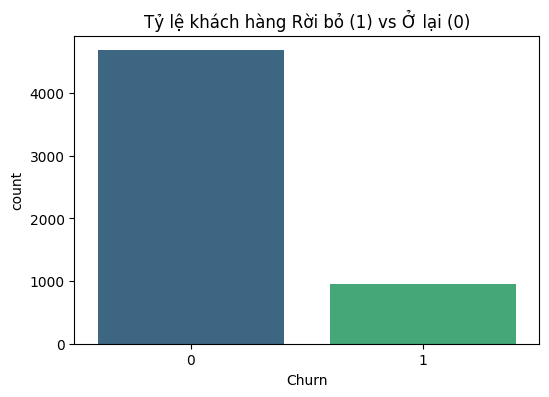

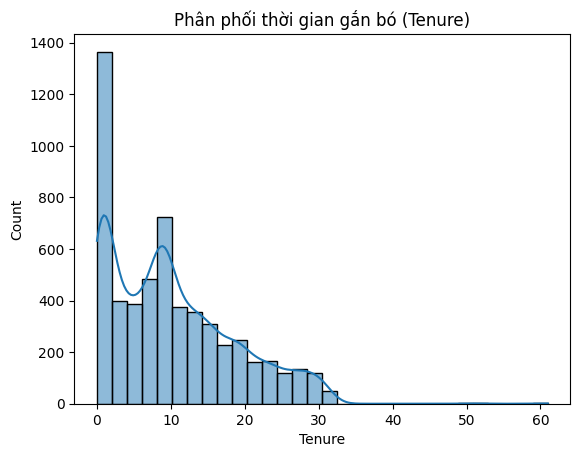

In [ ]:
# Kiểm tra tỷ lệ Churn
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Tỷ lệ khách hàng Rời bỏ (1) vs Ở lại (0)')
plt.show()

# Kiểm tra phân phối Tenure
sns.histplot(df['Tenure'], bins=30, kde=True)
plt.title('Phân phối thời gian gắn bó (Tenure)')
plt.show()

*   -> Dữ liệu Mất cân bằng churn(0) gấp 5 lần churn(1)
*   -> Khách hay bỏ ngay đoạn đầu thử nghiệm

### **Bước 3: Bivariate Analysis (Phân tích hành vi)**

3.1 Hành vi dựa trên Khiếu nại (Complain)

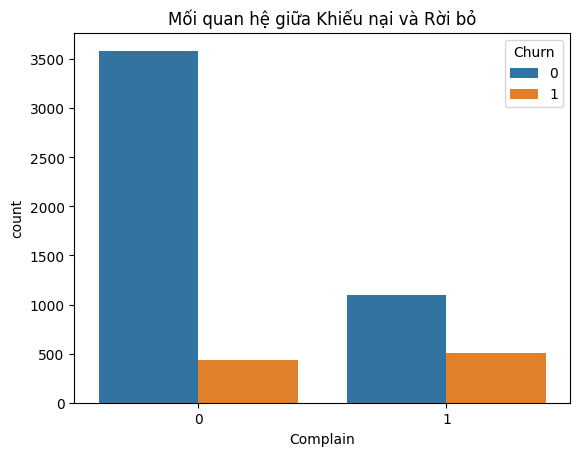

In [ ]:
sns.countplot(x='Complain', hue='Churn', data=df)
plt.title('Mối quan hệ giữa Khiếu nại và Rời bỏ')
plt.show()

-> khách complain rời đi nhiều hơn là không

3.2 Hành vi dựa trên thời gian gắn bó (Tenure) & Khoảng cách (WarehouseToHome)

/tmp/ipykernel_5085/1182189801.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Churn']==1]['Tenure'], label='Rời bỏ', shade=True)
/tmp/ipykernel_5085/1182189801.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Churn']==0]['Tenure'], label='Ở lại', shade=True)


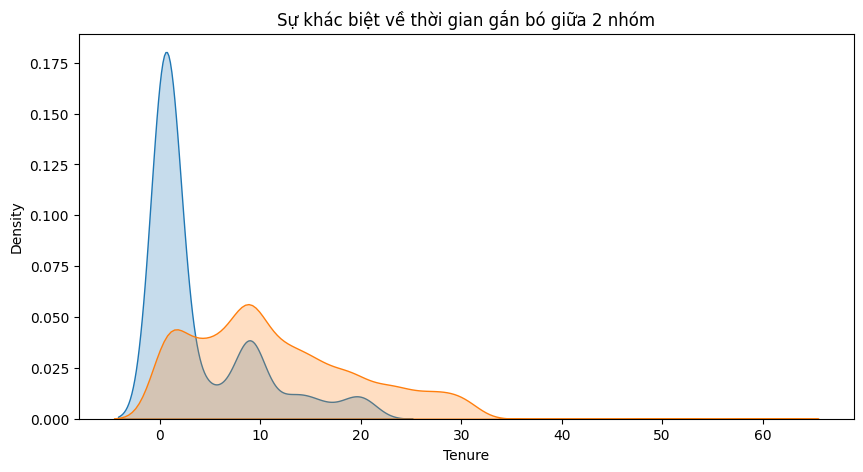

In [ ]:
plt.figure(figsize=(10,5))
sns.kdeplot(df[df['Churn']==1]['Tenure'], label='Rời bỏ', shade=True)
sns.kdeplot(df[df['Churn']==0]['Tenure'], label='Ở lại', shade=True)
plt.title('Sự khác biệt về thời gian gắn bó giữa 2 nhóm')
plt.show()

### **Bước 4: Detect and Treat Outliers**

In [ ]:
cols_to_fix = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear',
               'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

for col in cols_to_fix:
    data_col = df[col]
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Lọc Outlier
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    print(f"Đã làm sạch Outlier cho cột: {col}")

Đã làm sạch Outlier cho cột: Tenure
Đã làm sạch Outlier cho cột: WarehouseToHome
Đã làm sạch Outlier cho cột: HourSpendOnApp
Đã làm sạch Outlier cho cột: OrderAmountHikeFromlastYear
Đã làm sạch Outlier cho cột: CouponUsed
Đã làm sạch Outlier cho cột: OrderCount
Đã làm sạch Outlier cho cột: DaySinceLastOrder
Đã làm sạch Outlier cho cột: CashbackAmount


### **Bước 5: Feature Importance với Random Forest**

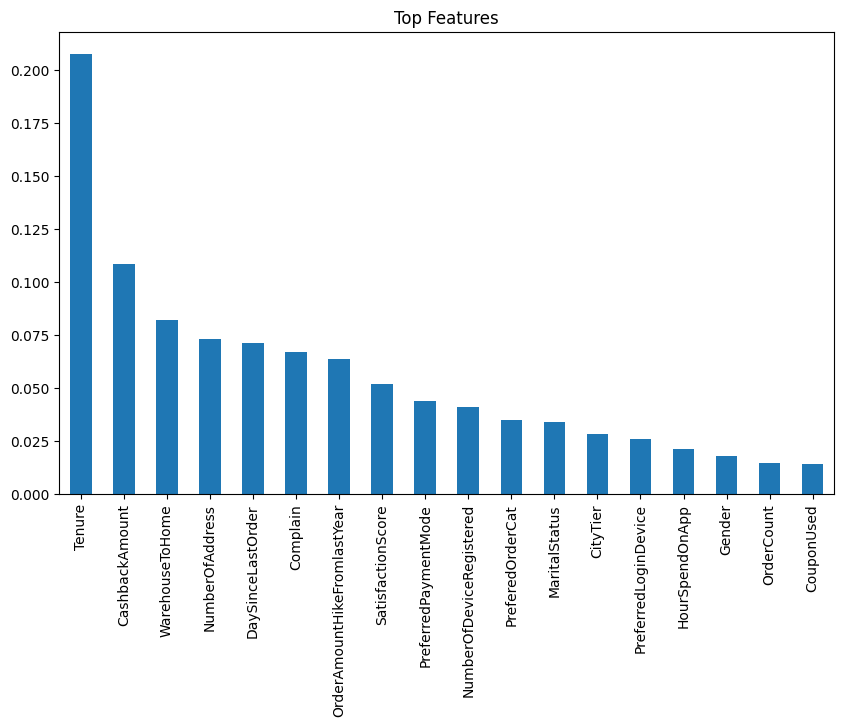

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Encoding các biến chữ thành số
le = LabelEncoder()
df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df[col])

# Train Base Model
X = df_encoded.drop(['Churn', 'CustomerID'], axis=1)
y = df_encoded['Churn']
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

# Trực quan hóa Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
importances.plot(kind='bar')
plt.title('Top Features')
plt.show()

## **B. Supervised Learning**

### **Bước 1: Chia dữ liệu (Train-Test Split)**

In [ ]:
from sklearn.model_selection import train_test_split

# Tách Features (X) và Target (y)
# Lưu ý: Loại bỏ CustomerID vì nó không có ý nghĩa dự báo
X = df_encoded.drop(['Churn', 'CustomerID'], axis=1)
y = df_encoded['Churn']

# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

Kích thước tập Train: (3066, 18)
Kích thước tập Test: (767, 18)


### **Bước 2: Huấn luyện mô hình Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Khởi tạo mô hình
# class_weight='balanced' sẽ giúp mô hình "ưu tiên" bắt đúng nhóm Churn (nhóm thiểu số)
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)

# Huấn luyện
rf_model.fit(X_train, y_train)

# Dự đoán
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1] # Lấy xác suất để tính điểm AUC

### **Bước 3: Đánh giá kết quả**

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       617
           1       0.94      0.87      0.90       150

    accuracy                           0.96       767
   macro avg       0.95      0.93      0.94       767
weighted avg       0.96      0.96      0.96       767

ROC-AUC Score: 0.9906


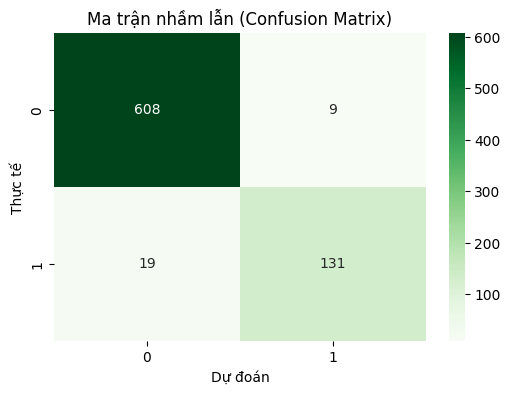

In [ ]:
# 1. In báo cáo chi tiết
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 2. Tính AUC-ROC
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# 3. Vẽ Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()

### **Bước 4: Hyperparameter Tuning**

In [ ]:
#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='balanced_accuracy')
grid_search.fit(X_train, y_train)

print("Best Parameters: ", grid_search.best_params_)


Best Parameters:  {'bootstrap': False, 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


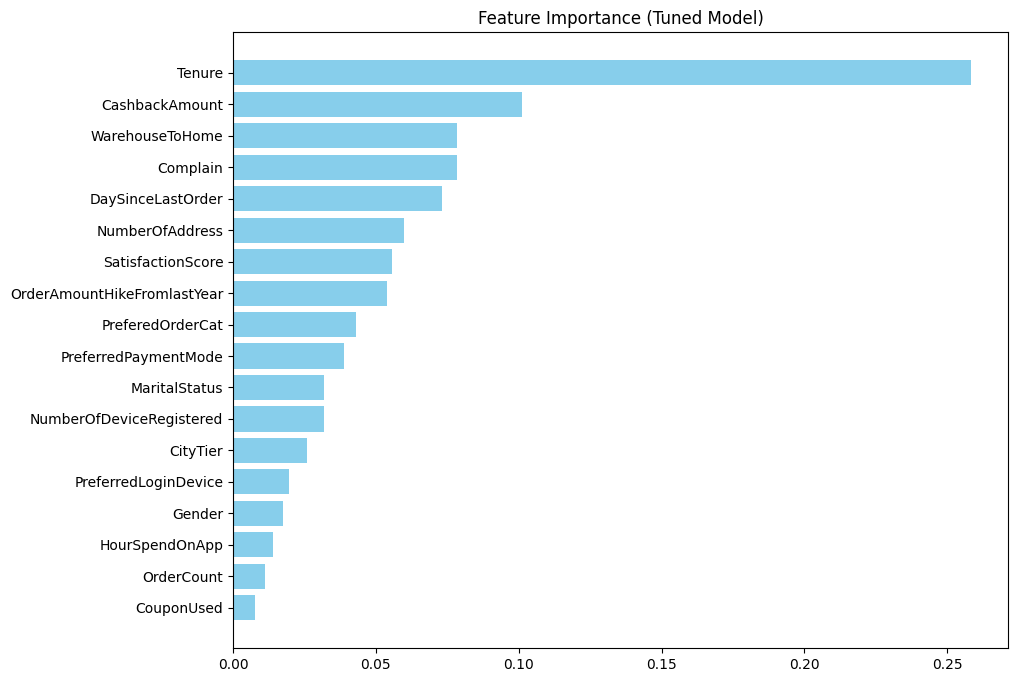

In [ ]:
#Feature Importance (Tuned Model)
best_clf = grid_search.best_estimator_
feats = {}
for feature, importance in zip(X.columns, best_clf.feature_importances_):
    feats[feature] = importance

importances = pd.DataFrame.from_dict(feats, orient='index').rename(columns={0: 'Gini-importance'})
importances = importances.sort_values(by='Gini-importance', ascending=True).reset_index()

plt.figure(figsize=(10, 8))
plt.barh(importances['index'], importances['Gini-importance'], color='skyblue')
plt.title('Feature Importance (Tuned Model)')
plt.show()

## **C. Unsupervised Learning**

### **Bước 1: Chuẩn bị dữ liệu và Tìm số cụm tối ưu (Elbow Method)**

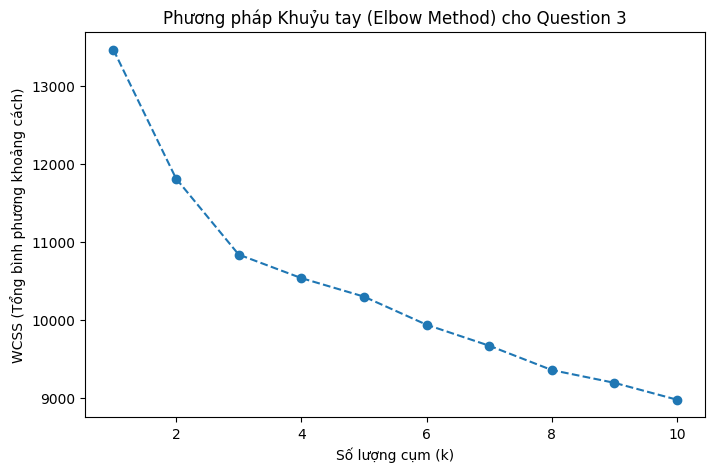

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Lọc ra tập dữ liệu chỉ gồm những khách hàng đã rời bỏ
churn_df = df_encoded[df_encoded['Churn'] == 1].copy()

# 2. Chọn các đặc trưng quan trọng để phân cụm (loại bỏ Target và ID)
features_to_cluster = churn_df.drop(['Churn', 'CustomerID'], axis=1)

# 3. Chuẩn hóa dữ liệu
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_to_cluster)

# 4. Vẽ biểu đồ Elbow để chọn K
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Phương pháp Khuỷu tay (Elbow Method) cho Question 3')
plt.xlabel('Số lượng cụm (k)')
plt.ylabel('WCSS (Tổng bình phương khoảng cách)')
plt.show()

### **Bước 2: Thực hiện phân cụm và Gán nhãn**

In [ ]:
# Thực hiện phân cụm
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
churn_df['Cluster'] = kmeans.fit_predict(scaled_features)

# Tính toán giá trị trung bình để phân tích đặc điểm (Profiling)
cluster_summary = churn_df.groupby('Cluster')[['Tenure', 'CashbackAmount', 'WarehouseToHome', 'Complain', 'SatisfactionScore']].mean()
print("--- Bảng tóm tắt đặc điểm nhóm rời bỏ ---")
print(cluster_summary)

--- Bảng tóm tắt đặc điểm nhóm rời bỏ ---
           Tenure  CashbackAmount  WarehouseToHome  Complain  \
Cluster                                                        
0        3.670103      129.014089        15.144330  0.522337   
1        4.273256      187.827616        21.273256  0.505814   
2        2.105263      150.167614        16.084211  0.550877   

         SatisfactionScore  
Cluster                     
0                 3.481100  
1                 3.470930  
2                 3.382456  


### **Bước 3: Phân tích đặc điểm từng cụm (Profiling)**

In [ ]:
# Tính toán giá trị trung bình các đặc trưng quan trọng theo từng cụm
cluster_summary = churn_df.groupby('Cluster')[['Tenure', 'CashbackAmount', 'WarehouseToHome', 'Complain', 'SatisfactionScore']].mean()
print("Bảng tóm tắt đặc điểm các nhóm khách hàng rời bỏ:")
display(cluster_summary)

Bảng tóm tắt đặc điểm các nhóm khách hàng rời bỏ:


,Tenure,CashbackAmount,WarehouseToHome,Complain,SatisfactionScore
Cluster,,,,,
0,3.670103,129.014089,15.144330,0.522337,3.481100
1,4.273256,187.827616,21.273256,0.505814,3.470930
2,2.105263,150.167614,16.084211,0.550877,3.382456


sẽ viết lại tùy theo bài đúng hay sai

### **Phân tích đặc điểm các cụm (Customer Profiling)**
#### **1.  Cluster 0 - Nhóm "Khách hàng lâu năm nhưng rời bỏ":**

*   Đặc điểm: Có Tenure trung bình cao nhất (6.7 tháng) và CashbackAmount cực
kỳ cao (Tầm 199).

*   Hành vi: Đây từng là những khách hàng trung thành và chi tiêu mạnh tay. Tuy nhiên, họ có điểm SatisfactionScore thấp nhất (2.91).

*   Lý do: Họ rời đi có thể do một trải nghiệm cực kỳ tệ gần đây hoặc họ cảm thấy sự chăm sóc không còn tương xứng với đóng góp lâu dài của họ.

#### **2.  Cluster 1 - Nhóm "Khách hàng mới nhạy cảm về giá":**

*   Đặc điểm: Tenure thấp nhất (3 tháng) và CashbackAmount cũng thấp nhất (133).

*   Hành vi: Nhóm này rời đi rất sớm. Với mức hoàn tiền thấp, họ không cảm thấy sự hấp dẫn về mặt tài chính để ở lại lâu hơn.

*   Lý do: Chưa hình thành thói quen sử dụng và không thấy đủ lợi ích kinh tế.

#### **3.  Cluster 2 - Nhóm "Rào cản Logistics & Khiếu nại":**

*   Đặc điểm: WarehouseToHome cao nhất (19.7) và tỷ lệ Complain cao nhất (0.56).

*   Hành vi: Tenure ở mức trung bình (3.5 tháng).

*   Lý do: Họ rời đi rõ ràng do khoảng cách giao hàng xa dẫn đến phí ship cao hoặc thời gian chờ đợi lâu, cộng thêm việc phát sinh khiếu nại nhiều nhất trong 3 nhóm.

### **Đề xuất Hành Động**
#### **1.  Cluster 0 - Nhóm "Khách hàng lâu năm nhưng rời bỏ":**

*   Hành động cụ thể: Gửi thư xin lỗi cá nhân hóa từ quản lý. Tặng gói Voucher nâng cấp (Loyalty Bonus) để kéo họ quay lại giai đoạn chi tiêu mạnh.

#### **2.  Cluster 1 - Nhóm "Khách hàng mới nhạy cảm về giá":**

*   Hành động cụ thể: Tăng mức Cashback cho 2-3 đơn hàng tiếp theo. Gửi các thông báo về sản phẩm mới phù hợp với sở thích để tăng sự gắn kết.


#### **3.  Cluster 2 - Nhóm "Rào cản Logistics & Khiếu nại":**
*   Hành động cụ thể: Tặng mã Freeship không giới hạn hoặc ưu tiên giao hàng hỏa tốc (Express Delivery) để bù đắp cho rào cản về vị trí địa lý.